# Cell Typing

Related to Extended Data Figure 2. 

Creates the processed data table `df_type_auto_typed.csv` used by other notebooks/analysis in this directory. 

## Inputs
- `layer-molecular_annotation.json`: contains annotation of the approximate molecular layer boundary plane, which is used to lay flat locations of cells and synapses in the y dimension (perpendicular to the molecular layer boundary.
- .csv files from the `morphology_cat/` directory (processed data created by `morphology_cat_createDF.ipynb`)
- `MG_partial-cat.csv`: data table of reconstructed cells with too much axon or dendrite out of volume to be included in the objective classification metrics used in this notebook analysis.
- .json cell reconstruction files in `'reconstructions_published'/`. 

## Prerequisites
- Jupyter launched from `efish_em/Notebooks_Jupyter/` (required for relative paths)
- `EM_data_published/` downloaded and placed as a sibling to `efish_em/` — see README
- Python environment set up per README instructions

# Setup

In [1]:
from pathlib import Path
import json
from scipy.spatial.distance import cdist
from sklearn.linear_model import LogisticRegression
from scipy.optimize import curve_fit
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster import hierarchy
from numpy import array, mean
from copy import deepcopy
from functools import reduce
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt


In [3]:
import sys
DIR_ROOT = Path.cwd().parent / 'efish_em'
if str(DIR_ROOT) not in sys.path:
    sys.path.insert(0, str(DIR_ROOT))
import AnalysisCode as efish

DATA_ROOT = Path.cwd().parent.parent / 'EM_data_published'
dirpath = DATA_ROOT / 'reconstructions_published'
figure_savepath = Path.cwd() / 'figures'
figure_savepath.mkdir(parents=True, exist_ok=True)
(figure_savepath / 'S2').mkdir(parents=True, exist_ok=True)


## User Configuration

Set the two variables below before running any other cells.
- `save_figures`: Set to `True` to save figure output files; `False` to display only.
- `figure_savepath`: Path to the directory where figures will be saved. Subdirectories for each figure will be created automatically.

In [2]:
# ── User configuration ──────────────────────────────────────────────────────────────────────────
save_figures = False  # Set to True to save figures to disk

# Set figure output directory (only used when save_figures = True):
figure_savepath = Path.cwd() / 'figures'  # saves inside Notebooks_Jupyter/figures/
# Alternatively, use an absolute path:
# figure_savepath = Path('/path/to/your/save/directory')
# ──────────────────────────────────────────────────────────────────────────────

In [ ]:
if save_figures:
    (figure_savepath / 'S2').mkdir(parents=True, exist_ok=True)

In [2]:
DATA_ROOT = Path.cwd().parent.parent / 'EM_data_published'
dirpath = DATA_ROOT / 'reconstructions_published'

vx_sizes = [16,16,30]

## Plotting style settings

In [3]:
filepath = Path.cwd().parent
filename = 'efish_em.mplstyle'
plt.style.use(filepath/filename)

In [4]:
cell_colors = efish.color_palette('cell')
structure_colors = efish.color_palette('structure')

## Molecular layer fit

In [5]:
neuroglancer_path = DATA_ROOT / 'data_processed_published/layer-molecular_annotation.json'

with open(Path(neuroglancer_path), 'r') as myfile: # 'p' is the dirpath and 'f' is the filename from the created 'd' dictionary
    neuroglancer_data = json.load(myfile)

set([item['name'] for item in neuroglancer_data['layers'] if item['type']=='annotation'])

nl_ = 'molecular'
neuroglancer_layer = next((item for item in neuroglancer_data['layers'] if item["name"] == nl_), None)
voxel_sizes = [16,16,30]

vertices = [[p['point'][i]*voxel_sizes[i] for i in range(3)] for p in neuroglancer_layer['annotations']] #[p['point'] for p in neuroglancer_layer['annotations']]#

x_pts = [p[0] for p in vertices]
y_pts = [p[1] for p in vertices]
z_pts = [p[2] for p in vertices]

# Perform curve fitting
popt, pcov = curve_fit(efish.func_planar_curve, (x_pts, z_pts), y_pts)

# Print optimized parameters
print(popt)


[ 2.71956920e+05 -5.43115077e-02 -1.87026179e-01 -3.46153667e-07
  2.31048373e-06  9.59242290e-13 -1.51595014e-11  6.68290149e-07]


## Load reconstruction files

In [6]:
nodefiles = efish.get_cell_filepaths(dirpath)

# cell types for all files in directory

## manual type

This represents any user-defined 'manual' cell typing that was used as a first pass to sort the cells during reconstruction. Run this to go through the cell-typing process utlizing algorithms and decision processes scripted in this notebook.

In [14]:
cell_type = {}
not_typed = []
for x,f in nodefiles.items():
    cell_data = efish.load_ecrest_celldata(f)
    try: ctype = cell_data['metadata']['cell-type']['manual']
    except Exception: 
        print('cell type not defined for this cell yet -- use cell_type.define(ctype,method)')
        not_typed.append(x)
        continue
    cell_type[int(x)] = ctype 
    
    if (ctype == []) | (ctype == ''):
        cell_type[int(x)]=np.NaN
        not_typed.append(x)# print(f'cell {x} is not cell-typed in json')
        
print('the following cells are not typed in the main network')
print(not_typed)        
        
df_type = pd.DataFrame(cell_type.items(),columns = ['id','cell_type'])

df_type.loc[df_type['cell_type'].isin(['dml']),'cell_type']='mli'
df_type.loc[df_type['cell_type'].isin(['grc-d']),'cell_type']='grc'
df_type.loc[df_type['cell_type'].isin(['grc-s']),'cell_type']='smpl'
df_type.loc[df_type['cell_type'].isin(['pfm']),'cell_type']='pf'

the following cells are not typed in the main network
[]


## from file

Un-comment and run the following read command to import final (processed) cell type file as df_type. After processing the cell types, the final version needs to be imported to create the figures representing the correct cell type assignments (ie the versions of the figures published in the paper). 

In [9]:
# df_type= pd.read_csv(DATA_ROOT / 'data_processed_published/df_type_auto_typed.csv')

# Create MG axon and basal dendrite mesh in colab

Use 'morphology_cat_createDF.ipynb'

old method in colab:
https://colab.research.google.com/drive/1wZ2v1ZFZ6fdlo_hJ9Hy_6w_6wOSe1NDe?usp=sharing

# Cell structures from nodes

In [23]:
csv_dir = DATA_ROOT / 'data_processed_published/morphology_cat'

df_ax_list = []
for f in ['df_nodes_ax_type1.csv','df_nodes_ax_type2.csv']:
    df_ax_list.append(pd.read_csv(csv_dir / f))
df_ax = pd.concat(df_ax_list)
df_ax.set_index('id',inplace=True)
df_ax = df_ax.loc[:, ~df_ax.columns.str.contains('^Unnamed')]

df_bd_list = []
for f in ['df_nodes_bd_type1.csv','df_nodes_bd_type2.csv']:
    df_bd_list.append(pd.read_csv(csv_dir / f))
df_bd = pd.concat(df_bd_list)
df_bd.set_index('id',inplace=True)
df_bd = df_bd.loc[:, ~df_bd.columns.str.contains('^Unnamed')]

df_ad_list = []
for f in ['df_nodes_ad_type1.csv','df_nodes_ad_type2.csv']:
    df_ad_list.append(pd.read_csv(csv_dir / f))
df_ad = pd.concat(df_ad_list)
df_ad.set_index('id',inplace=True)
df_ad = df_ad.loc[:, ~df_ad.columns.str.contains('^Unnamed')]

# Merge morphology stats with soma and cell type info

In [ ]:
df_soma = efish.measure_soma(nodefiles)

# Compute y-adjusted values
coords = df_soma[['soma_x', 'soma_z']].values * 1000
yoffsets = np.array([efish.func_planar_curve((x, z), *popt) for x, z in coords])
df_soma['soma_y_adj'] = df_soma['soma_y'] - yoffsets / 1000

data_frames = [df_ax,df_bd,df_ad,df_type[df_type['id'].isin(df_ax.index)],df_soma[df_soma['id'].isin(df_ax.index)]] 

df_merged = reduce(lambda  left,right: pd.merge(left,right,on=['id'],
                                            how='outer'), data_frames)
df_merged = df_merged.loc[:, ~df_merged.columns.str.contains('^Unnamed')]

# analyze multidimensional morphology space

In [ ]:
df_morph = deepcopy(df_merged[['id',
                    'ax_std_x','ax_std_z',
                    'bd_std_x','bd_std_z',
                    'ad_count_y',#'ad_std_y','ad_std_x','ad_std_z',
                    'soma_diam',#'soma_y_adj',
                               'cell_type']]).set_index(['id'])

print(len(df_morph[df_morph.isna().any(axis=1)]))
# df_morph[df_morph.isna().any(axis=1)]#: Returns a boolean Series indicating whether each row contains at least one NaN value. #[['soma_diam']]


## create class column

In [27]:
df_morph.loc[df_morph['cell_type'].isin(['sg1','sg2']),'class'] = 'sg'
df_morph.loc[df_morph['cell_type'].isin(['mg1','mg2']),'class'] = 'mg'

## merge out-of-volume metadata

In [29]:
df = pd.read_csv(DATA_ROOT / 'data_processed_published/MG_partial-cat.csv')
df_morph = pd.merge(df_morph, df, on='id', how='left')

## Hierachical clustering

In [ ]:
mask = df_morph['ov'].isin([np.NaN])
features = ['id','soma_diam','bd_std_x', 'ax_std_x', 'ax_std_z','bd_std_z','ad_count_y']#,'ad_std_y']#,'ad_std_x','ad_std_z']# ,'soma_y_adj'

df_cluster = df_morph.loc[mask,features].set_index('id')#df_morph.loc[mask,features]
df_cluster.dropna(axis=0,inplace=True) # remove any cells from analysis that have NaN for any of the features

# standardize within each feature (Each column of dataframe)
df_cluster = df_cluster.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

Z = hierarchy.linkage(df_cluster, method='ward', metric='euclidean',optimal_ordering=True) #

### visualize clustering

In [33]:
def fancy_dendrogram(*args, **kwargs):
    max_d = kwargs.pop('max_d', None)
    if max_d and 'color_threshold' not in kwargs:
        kwargs['color_threshold'] = max_d
    annotate_above = kwargs.pop('annotate_above', 0)

    ddata = dendrogram(*args, **kwargs)

    if not kwargs.get('no_plot', False):
        # plt.title('Hierarchical Clustering Dendrogram (truncated)')
        plt.xlabel('sample index or (cluster size)')
        plt.ylabel('distance')
        for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
            x = 0.5 * sum(i[1:3])
            y = d[1]
            if y > annotate_above:
                plt.plot(x, y, 'o', c=c)
                plt.annotate("%.3g" % y, (x, y), xytext=(0, -5),
                             fontsize=6,
                             textcoords='offset points',
                             va='top', ha='center')
        if max_d:
            plt.axhline(y=max_d, c='k')
    return ddata


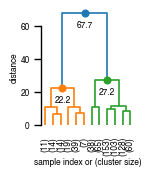

In [37]:
max_d = 40
plt.figure(figsize=(1.2,1.5))
fancy_dendrogram(
    Z,
    truncate_mode='lastp',
    p=12,
    leaf_rotation=90.,
    leaf_font_size=6.,
    show_contracted=True,
    annotate_above=15,
    # max_d=max_d,
    # ax = ax# plot a horizontal cut-off line
)
ax=plt.gca()
ax.set_ylim(0,70)

sns.despine(bottom=True,trim=True)

if save_figures:
    plt.savefig((figure_savepath / 'S2') / f'mg_sg_dendrogram.svg', transparent=True)

### categorize class based on clustering

In [73]:
max_d = 40
df_cluster['label'] = hierarchy.fcluster(Z, max_d, criterion='distance')

df_cluster.reset_index(inplace=True)

df_cluster = pd.merge(df_cluster,df_morph[['id','class']],on='id')

In [74]:
# how many of each class are in each cluster (label)?
df_cluster.groupby(['label','class'])['id'].count()

label  class
1      mg       104
2      sg       547
Name: id, dtype: int64

In [339]:
df_cluster[(df_cluster['label']==1) & (df_cluster['class']=='sg')]['id'].values

array([213501262, 387197529,  41579854,  41843700, 558346897, 559551706,
       127607174, 127672247, 300226567, 302003735, 302544942, 303166992,
       387382792, 472051969, 472361842, 475781099, 558934217])

In [182]:
df_cluster[(df_cluster['label']==2) & (df_cluster['class']=='mg')]['id'].values

array([], dtype=int64)

### adjust df_type and re-save as df_type_auto

In [340]:
for c in df_cluster[(df_cluster['label']==1) & (df_cluster['class']=='sg')]['id'].values:
    if df_type.loc[df_type[df_type['id'].isin([c])].index,'cell_type'].values[0] == 'sg1':
        df_type.loc[df_type[df_type['id'].isin([c])].index,'cell_type'] = 'mg1' 
    if df_type.loc[df_type[df_type['id'].isin([c])].index,'cell_type'].values[0] == 'sg2':
        df_type.loc[df_type[df_type['id'].isin([c])].index,'cell_type'] = 'mg2' 

In [341]:
for c in df_cluster[(df_cluster['label']==2) & (df_cluster['class']=='mg')]['id'].values:
    if df_type.loc[df_type[df_type['id'].isin([c])].index,'cell_type'].values[0] == 'mg1':
        df_type.loc[df_type[df_type['id'].isin([c])].index,'cell_type'] = 'sg1' 
    if df_type.loc[df_type[df_type['id'].isin([c])].index,'cell_type'].values[0] == 'mg2':
        df_type.loc[df_type[df_type['id'].isin([c])].index,'cell_type'] = 'sg2' 

In [342]:
df_type.to_csv(DATA_ROOT / 'data_processed_published/df_type_auto.csv')

# Type 1 vs Type 2

The plots generated here will not reproduced published figures until the notebook is re-run with loading the saved 'df_type_auto_typed.csv' cell typing. One the first pass through the notebook, the figure coloring will reflect the manual cell typing that was done subjectively as a first pass, not the cell typing used in the paper. 

In [365]:
df_morph = deepcopy(df_merged[['id',
                    'ax_50%_y','bd_50%_y',
                    'bd_std_y','ax_min_y','ax_max_y',
                    'ax_count_y','bd_count_y',
                    'soma_diam','soma_y_adj',
                               'cell_type']]).set_index(['id'])

for col in ['ax_50%_y','bd_50%_y','soma_y_adj']:
    df_morph[col] = df_morph[col]/1000 * -1
for col in ['soma_diam']:
    df_morph[col] = df_morph[col]/1000 

df = pd.read_csv(dirpath / 'metadata/MG_partial-cat.csv')
df_morph = pd.merge(df_morph, df, on='id', how='left')
# df_morph.fillna(False, inplace=True)

df_morph.fillna(False, inplace=True)

## mg

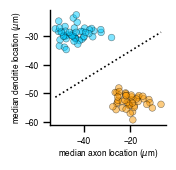

In [366]:
mask = (df_morph['ov'].isin([False])) & (df_morph['cell_type'].isin(['mg1','mg2']))

X=df_morph[mask][['ax_50%_y','bd_50%_y']]
y=df_morph[mask]['cell_type']

lr = LogisticRegression()
lr.fit(X,y)

# mask = (df_morph['cell_type'].isin(['mg1','mg2']))

fig, ax = plt.subplots(figsize=(1.5,1.5))

sns.scatterplot(ax=ax,data=df_morph[mask],x='ax_50%_y',y='bd_50%_y',hue='cell_type',
                palette=cell_colors, alpha = 0.5,edgecolor='black',
               legend=False)

# Get the current axis limits
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

x = np.linspace(min(df_morph[mask]['ax_50%_y']), max(df_morph[mask]['ax_50%_y']), 100)
y = (-lr.intercept_ - lr.coef_[0][0]*x) / lr.coef_[0][1]
plt.plot(x,y,color='black',linestyle='dotted')

ax.set_ylim(y_min,y_max)
ax.set_xlim(x_min,x_max)

# Set the font size for the axis labels
ax.set_xlabel('median axon location ($\\mu$m)')
ax.set_ylabel('median dendrite location ($\\mu$m)')


if save_figures:
    plt.savefig((figure_savepath / 'S2') / f'CellType_mg_ax-bd_linear-classifier.svg', transparent=True)

## sg

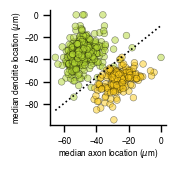

In [367]:
mask = (df_morph['ov'].isin([False])) & (df_morph['cell_type'].isin(['sg1','sg2']))

X=df_morph[mask][['ax_50%_y','bd_50%_y']]
y=df_morph[mask]['cell_type']

lr = LogisticRegression()
lr.fit(X,y)

# mask = (df_morph['cell_type'].isin(['mg1','mg2']))

fig, ax = plt.subplots(figsize=(1.5,1.5))

sns.scatterplot(ax=ax,data=df_morph[mask],x='ax_50%_y',y='bd_50%_y',hue='cell_type',
                palette=cell_colors, alpha = 0.5,edgecolor='black',
               legend=False)

# Get the current axis limits
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

x = np.linspace(min(df_morph[mask]['ax_50%_y']), max(df_morph[mask]['ax_50%_y']), 100)
y = (-lr.intercept_ - lr.coef_[0][0]*x) / lr.coef_[0][1]
plt.plot(x,y,color='black',linestyle='dotted')


ax.set_ylim(y_min,y_max)
ax.set_xlim(x_min,x_max)

# Set the font size for the axis labels
ax.set_xlabel('median axon location ($\\mu$m)')
ax.set_ylabel('median dendrite location ($\\mu$m)')


#if save_figures:
    plt.savefig((figure_savepath / 'S2') / f'CellType_sg_ax-bd_linear-classifier.svg', transparent=True)

In [ ]:
df_result = deepcopy(df_morph[mask])

df_result.loc[:,'label'] = lr.predict(X)

df_result.groupby(['cell_type','label']).count()

In [371]:
df_result[df_result['cell_type'].isin(['sg1']) & df_result['label'].isin(['sg2']) ]['id'].values

array([128751464, 215897023, 389658102, 393450060,  44180995, 645287544])

### adjust df_type and re-save as df_type_auto

In [372]:
for c in df_result[(df_result['label']=='sg2') & (df_result['cell_type']=='sg1')]['id'].values:
    df_type.loc[df_type[df_type['id'].isin([c])].index,'cell_type'] = 'sg2' 
    

In [373]:
for c in df_result[(df_result['label']=='sg1') & (df_result['cell_type']=='sg2')]['id'].values:
    df_type.loc[df_type[df_type['id'].isin([c])].index,'cell_type'] = 'sg1' 

In [375]:
df_type.to_csv(DATA_ROOT / 'data_processed_published/df_type_auto_typed.csv')